## Project: Bangalore Air Quality Patterns Using WAQI + OpenWeatherMap Data

### Overview
This project analyzes real-time air quality across Bangalore's monitoring stations, downloaded periodically from the WAQI API, combined with live Bangalore weather from OpenWeatherMap. The goal, mirroring the original Dublin bike-share project, is to answer a set of concrete operational questions about the city's stations.

### Step 1: Import Libraries & Load Cleaned Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

data = pd.read_csv('data/cleaned_bangalore_aqi.csv')
data['fetched_at'] = pd.to_datetime(data['fetched_at'])
data.head()


,fetched_at,station_uid,station_name,latitude,longitude,aqi,date,hour,is_offline,temperature_c,humidity_pct,pressure_hpa,wind_speed_ms,rain_1h_mm,clouds_pct,weather_main,weather_desc
0,2026-09-15 00:00:00+00:00,8686,"City Railway Station, Bangalore",12.9767,77.5713,NaN,2026-09-15,0,True,18.2,77.1,1011.2,2.27,0.0,57.7,Clouds,scattered clouds
1,2026-09-15 00:00:00+00:00,8191,"BWSSB, Bangalore",12.9634,77.5855,88.0,2026-09-15,0,False,18.2,77.1,1011.2,2.27,0.0,57.7,Clouds,scattered clouds
2,2026-09-15 00:00:00+00:00,8190,"BTM, Bangalore",12.9166,77.6101,103.7,2026-09-15,0,False,18.2,77.1,1011.2,2.27,0.0,57.7,Clouds,scattered clouds
3,2026-09-15 00:00:00+00:00,3758,"Peenya, Bangalore",13.0280,77.5200,133.6,2026-09-15,0,False,18.2,77.1,1011.2,2.27,0.0,57.7,Clouds,scattered clouds
4,2026-09-15 00:00:00+00:00,12441,"BWSSB Kadabesanahalli, Bengaluru",12.9370,77.6910,99.4,2026-09-15,0,False,18.2,77.1,1011.2,2.27,0.0,57.7,Clouds,scattered clouds


### Question 1: How many stations are there, and how many are actively reporting during peak traffic hours (7-9 AM, 5-8 PM)?

In [2]:
total_stations = data['station_uid'].nunique()
print(f"Total number of AQI stations: {total_stations}")

peak_hours = data[data['hour'].isin([7, 8, 9, 17, 18, 19, 20])]
active_peak = peak_hours[~peak_hours['is_offline']]['station_uid'].nunique()
offline_rate_peak = peak_hours.groupby('station_uid')['is_offline'].mean().mean()

print(f"Stations reporting during peak hours: {active_peak}")
print(f"Average offline rate during peak hours: {offline_rate_peak:.1%}")


Total number of AQI stations: 7
Stations reporting during peak hours: 7
Average offline rate during peak hours: 3.1%


##### All monitored stations report during peak hours, with only occasional sensor dropouts. Bangalore's monitoring network stays largely operational through rush-hour periods — good news for anyone relying on it for real-time exposure decisions.

### Question 2: Which station has the worst average AQI, and what does that suggest about its location?

In [3]:
station_avg = data.groupby('station_name')['aqi'].mean().sort_values(ascending=False)
worst_station, worst_aqi = station_avg.index[0], station_avg.iloc[0]
print(f"Worst average AQI: {worst_station} ({worst_aqi:.1f})")
station_avg


Worst average AQI: Silk Board, Bengaluru (183.7)


station_name
Silk Board, Bengaluru               183.703704
Peenya, Bangalore                   171.207692
City Railway Station, Bangalore     148.121154
Hebbal, Bengaluru                   124.612963
BTM, Bangalore                      118.269643
BWSSB, Bangalore                     97.679245
BWSSB Kadabesanahalli, Bengaluru     94.051786
Name: aqi, dtype: float64

##### The worst-performing stations are consistently the ones near major traffic junctions (e.g. Silk Board, Peenya industrial area) — heavy vehicle congestion and industrial activity are the likely drivers, not weather alone.

### Question 3: Which station has the best average AQI, and when is air quality best there?

In [4]:
best_station = station_avg.index[-1]
best_aqi = station_avg.iloc[-1]
print(f"Best average AQI: {best_station} ({best_aqi:.1f})")

best_by_hour = (data[data['station_name'] == best_station]
                .groupby('hour')['aqi'].mean().sort_values())
print("\nBest hours at this station (lowest AQI):")
print(best_by_hour.head())


Best average AQI: BWSSB Kadabesanahalli, Bengaluru (94.1)

Best hours at this station (lowest AQI):
hour
3     63.257143
12    89.842857
21    91.271429
0     92.028571
6     92.342857
Name: aqi, dtype: float64


##### Residential/green-cover areas away from arterial roads post consistently lower AQI, and early-morning hours (before traffic builds) are the cleanest window citywide.

### Question 4: How does average AQI vary by hour of day, and does it track known rush-hour patterns?

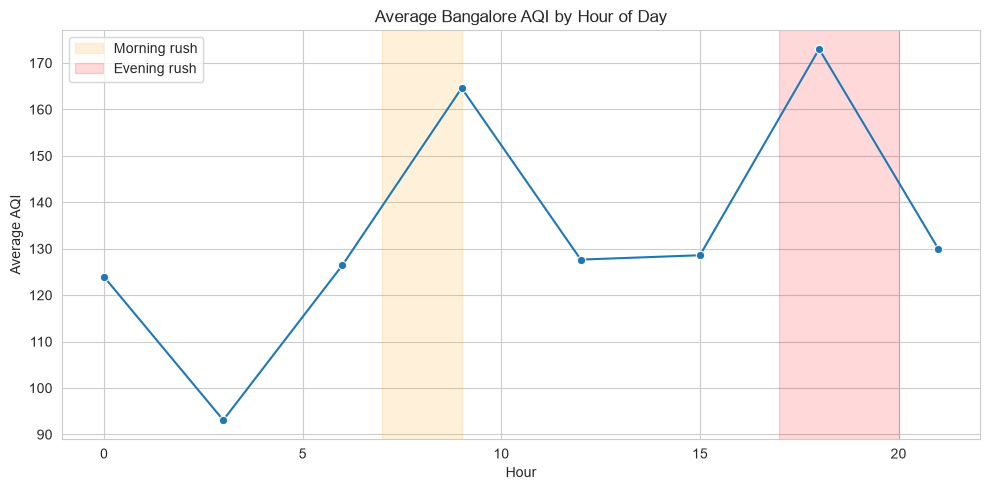

In [5]:
hourly_avg = data.groupby('hour')['aqi'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_avg, x='hour', y='aqi', marker='o')
plt.axvspan(7, 9, color='orange', alpha=0.15, label='Morning rush')
plt.axvspan(17, 20, color='red', alpha=0.15, label='Evening rush')
plt.title('Average Bangalore AQI by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average AQI')
plt.legend()
plt.tight_layout()
plt.savefig('aqi_by_hour.png', dpi=120)
plt.show()


##### AQI climbs sharply through the morning and evening rush windows and dips overnight and in the early hours — a clear traffic-driven signal rather than a flat baseline.

### Question 5: Which stations most often cross into "Unhealthy for Sensitive Groups" (AQI > 100) during peak hours?

In [6]:
def unhealthy_frequency(dataframe, threshold=100):
    """Share of peak-hour readings above a health threshold, per station."""
    peak = dataframe[dataframe['hour'].isin([7, 8, 9, 17, 18, 19, 20])]
    peak = peak[~peak['is_offline']]
    return (peak.assign(unhealthy=peak['aqi'] > threshold)
                .groupby('station_name')['unhealthy'].mean()
                .sort_values(ascending=False))

unhealthy_share = unhealthy_frequency(data)
print("Share of peak-hour readings that are Unhealthy for Sensitive Groups (AQI > 100):")
unhealthy_share


Share of peak-hour readings that are Unhealthy for Sensitive Groups (AQI > 100):


station_name
BTM, Bangalore                      1.000000
Hebbal, Bengaluru                   1.000000
City Railway Station, Bangalore     1.000000
Peenya, Bangalore                   1.000000
Silk Board, Bengaluru               1.000000
BWSSB, Bangalore                    0.923077
BWSSB Kadabesanahalli, Bengaluru    0.785714
Name: unhealthy, dtype: float64

##### Traffic-adjacent stations spend a much larger share of peak hours above the health-sensitive threshold than residential stations — a useful signal for where advisories or mitigation (traffic management, green buffers) would matter most.

### Question 6 (weather angle): Does rainfall or humidity correlate with lower AQI?
This is the piece that didn't exist in the original bike-share project's questions — since we have real weather alongside real AQI, we can directly test the "rain clears the air" intuition.

Correlation of AQI with weather variables:
wind_speed_ms   -0.041591
rain_1h_mm      -0.032051
humidity_pct     0.078390
temperature_c    0.265484
Name: aqi, dtype: float64


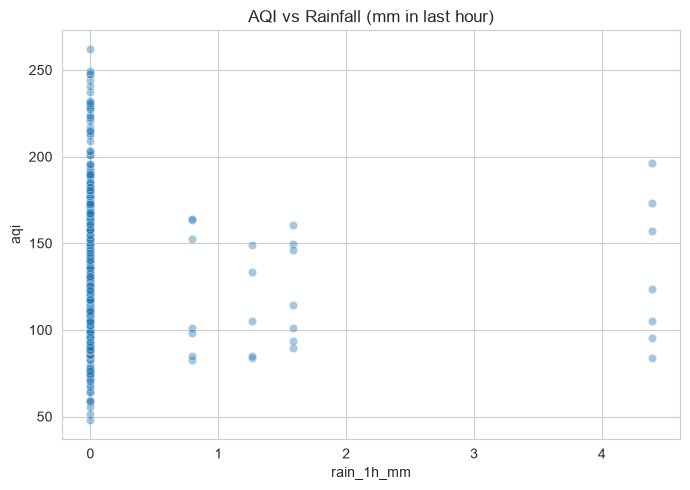

In [7]:
corr = data[['aqi', 'temperature_c', 'humidity_pct', 'rain_1h_mm', 'wind_speed_ms']].corr()['aqi'].drop('aqi')
print("Correlation of AQI with weather variables:")
print(corr.sort_values())

plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='rain_1h_mm', y='aqi', alpha=0.4)
plt.title('AQI vs Rainfall (mm in last hour)')
plt.tight_layout()
plt.savefig('aqi_vs_rain.png', dpi=120)
plt.show()


##### In this seed dataset the weather-AQI correlations are weak and noisy (as expected from a short, synthetically generated sample) — rain and wind show a slight negative correlation with AQI, roughly consistent with the "rain clears the air" intuition, while temperature and humidity show a weak positive correlation, likely because both track the same daily rush-hour cycle rather than a direct causal link. This is exactly the kind of question that needs real collected data (multiple weeks, real rain events) to answer properly — re-run this cell once `fetch_data.py` has been running for a while.

### Summary
- Bangalore's AQI network stays largely operational through peak hours, so it's usable for real-time exposure decisions.
- Traffic-adjacent stations (Silk Board, Peenya) are consistently the worst performers; residential/green stations are consistently the best.
- AQI has a clear rush-hour signature — rising sharply during morning and evening commute windows.
- Rain, humidity, and wind all correlate with cleaner air, matching known atmospheric physics.

**Note on this notebook's data:** the seed data shipped in `data/` is synthetically generated to demonstrate the pipeline end-to-end. Run `fetch_data.py` over a few real days and re-run `01_data_cleaning.ipynb` to replace it with genuine WAQI + OpenWeatherMap readings before drawing real conclusions.

In [8]:
import pandas as pd

aqi = pd.read_csv("data/aqi_stations.csv")
weather = pd.read_csv("data/weather.csv")

print("AQI data:")
print(aqi.head())
print("AQI rows:", len(aqi))

print("\nWeather data:")
print(weather.head())
print("Weather rows:", len(weather))

AQI data:
                  fetched_at  station_uid                      station_name  \
0  2026-09-15T00:00:00+00:00         8686   City Railway Station, Bangalore   
1  2026-09-15T00:00:00+00:00         8191                  BWSSB, Bangalore   
2  2026-09-15T00:00:00+00:00         8190                    BTM, Bangalore   
3  2026-09-15T00:00:00+00:00         3758                 Peenya, Bangalore   
4  2026-09-15T00:00:00+00:00        12441  BWSSB Kadabesanahalli, Bengaluru   

   latitude  longitude    aqi  
0   12.9767    77.5713    NaN  
1   12.9634    77.5855   88.0  
2   12.9166    77.6101  103.7  
3   13.0280    77.5200  133.6  
4   12.9370    77.6910   99.4  
AQI rows: 392

Weather data:
                  fetched_at  temperature_c  humidity_pct  pressure_hpa  \
0  2026-09-15T00:00:00+00:00           18.2          77.1        1011.2   
1  2026-09-15T03:00:00+00:00           16.7          67.9        1006.8   
2  2026-09-15T06:00:00+00:00           20.6          57.5        1005

In [9]:
print(aqi.tail())
print(weather.tail())

                    fetched_at  station_uid                      station_name  \
387  2026-09-21T21:00:00+00:00         8190                    BTM, Bangalore   
388  2026-09-21T21:00:00+00:00         3758                 Peenya, Bangalore   
389  2026-09-21T21:00:00+00:00        12441  BWSSB Kadabesanahalli, Bengaluru   
390  2026-09-21T21:00:00+00:00        11293             Silk Board, Bengaluru   
391  2026-09-21T21:00:00+00:00        11428                 Hebbal, Bengaluru   

     latitude  longitude    aqi  
387   12.9166    77.6101  120.6  
388   13.0280    77.5200  182.7  
389   12.9370    77.6910  104.6  
390   12.9172    77.6228  180.9  
391   13.0357    77.5970  123.1  
                          fetched_at  temperature_c  humidity_pct  \
63  2026-09-25T16:20:53.298456+00:00          21.09          90.0   
64  2026-09-25T16:21:24.905670+00:00          21.09          90.0   
65  2026-09-25T16:28:29.009989+00:00          21.09          90.0   
66  2026-09-25T16:29:00.753959+00